# Costs are 'sticky'. Can you trade the firms that don't cut them? 📎
### A real, textbook accounting fact — SG&A clings on the way down — that turns out to sort *nothing* in the stock market

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sticky costs%3F: Confirmed](https://img.shields.io/badge/Sticky_costs%3F-Confirmed-8b949e?style=flat-square)

Here's an accounting fact with a name and a famous paper behind it. When sales rise, a company's overhead — salespeople, marketing, admin, the SG&A line — rises with it. But when sales *fall*, that overhead comes down **more slowly**: managers hesitate to fire the sales team or kill a campaign they might need again next quarter. Costs are **sticky** on the way down. Anderson, Banker & Janakiraman measured it in 2003: SG&A rises ~0.55% per 1% sales gain but falls only ~0.35% per 1% sales loss.

The trading pitch writes itself: a firm whose costs stay sticky into a downturn is **badly disciplined** — it should earn less. So short the sticky firms, buy the lean ones. Sounds airtight. It isn't.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 33 large US filers that report SG&A on EDGAR (only 25 ever *identify* stickiness — you need real sales declines to measure it), 2015→2026; a genuinely **thin, cyclical-tilted, noisy panel**. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sga_stickiness import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 33, 'n_ident': 25, 'n_events': 314, 'end_lo': '2015-09-26', 'end_hi': '2026-05-03', 'fp_prices': '2cf202cb4854', 'abj_b1': 0.651, 'abj_b1p2': 0.554, 'abj_b2': -0.097, 'n_sticky': 12, 'n_total': 25, 'n_months': 101, 'avg_n': 11.0, 'ls_span_lo': '2015-12-31', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': -28.6, 'ls_ann': -3.43, 'ls_t_iid': -0.57, 'ls_t_nw': -0.45, 'ls_sharpe': -0.2, 'ls_hit': 48, 'ls_long_bps': 125.2, 'ls_short_bps': 153.7, 'ls_turn': 0.07, 'ls_cum': 0.66, 'ls120_mean_bps': 28.1, 'ls120_t_nw': 0.66, 'drift': {21: (313, 1.37, 1.72, -0.35, -0.32, 50, 0.6233), 63: (301, 5.92, 4.65, 1.27, 0.57, 54, 0.2546), 126: (296, 10.77, 11.52, -0.76, -0.24, 54, 0.5872)}, 'mono63': (4.65, 4.85, 5.92), 'era_early_n': 54, 'era_early_bps': 14.4, 'era_early_t': 0.2, 'era_late_n': 47, 'era_late_bps': -78.0, 'era_late_t': -0.74, 'roa_n': 226, 'roa_slope': 0.0004, 'roa_t': 0.15, 'roa_r2': 0.0, 'roa_corr': 0.01, 'roa_top': 0.34, 'roa_bot': 0.48, 'roa_spread': -0.14, 'net': {(10, 50): (-34.1, -4.1, -0.54, -0.23), (20, 100): (-39.7, -4.77, -0.63, -0.27)}, 'syn_null_mean': 0.02, 'syn_null_sd': 0.87, 'syn_null_fire': 0, 'syn_null_seeds': 10, 'syn_planted_bps': 156.9, 'syn_planted_t': 3.16}


real cache present: True | events: 314 | names: 25


## The answer first

| Question | Answer |
|---|---|
| Are SG&A costs really **sticky**? | **Yes.** Across the panel SG&A rises **+0.65%** per 1% sales gain but falls only **+0.55%** per 1% sales loss (β₂ = -0.10). The 2003 effect replicates. |
| Do **sticky-cost firms under-earn**? | **No — not in any direction we can find.** A long-short that buys the leanest firms and shorts the stickiest earns **-3.4%/yr** — the *wrong sign* and indistinguishable from luck (robust *t* = **-0.45**), and it flips sign if you nudge the settings. |
| Does stickiness at least predict weaker **profits**? | **No.** The stickiest third of firms go on to earn essentially the same as the leanest — a ROA-change gap of **-0.14 pp** (correlation +0.01). Nothing. |
| Can you trade it? | **No.** It's the wrong sign and insignificant before costs — there's nothing to charge costs against. |

> A real, measurable behaviour of costs. No signal in the stock, no signal in the future earnings. That gap is the whole study.

## 1 · The claim

> *"SG&A is sticky — it falls slower than it rises. A firm that lets costs cling into a sales decline is undisciplined and should under-earn. Short the sticky, buy the lean."*

The premise (costs are sticky) is **true and well-replicated** — it's one of the most cited results in management accounting. The leap is the second sentence: that a regression coefficient anyone can compute from years-old public filings tells you which stocks will win.

## 2 · So what?

If a firm's *cost-cutting reflexes* — estimable from its own 10-Ks — predicted its stock, that would be a tidy quality anomaly: no alt-data, just the income statement. That's exactly why it deserves suspicion. Everyone can run the ABJ regression. If markets price public operating characteristics at all, a decade-old cost elasticity is the kind they should have long since absorbed.

## 3 · How would we even know?

- **The signal.** For each firm, estimate its **cost stickiness** (how much less SG&A falls on the way down than it rises on the way up) using *only* the filings public at each point in time — no peeking at the future.
- **The return test.** Each month, rank firms from leanest to stickiest, buy the lean third, short the sticky third, hold a month. Does the spread make money — and can we tell it from noise?
- **The profits test.** Do the stickiest firms actually go on to earn less (weaker return on assets)? If the 'weak discipline' story is right, they should.
- **The mirage check.** If the return spread can't beat a coin-flip relabelling of the firms, it's not a signal, however good the story sounds.

## 4 · The teardown — let's actually look

**First, the part that's true: are costs really sticky?** For every firm-quarter we line up the year-over-year change in SG&A against the change in sales, separately for quarters when sales rose and quarters when they fell.

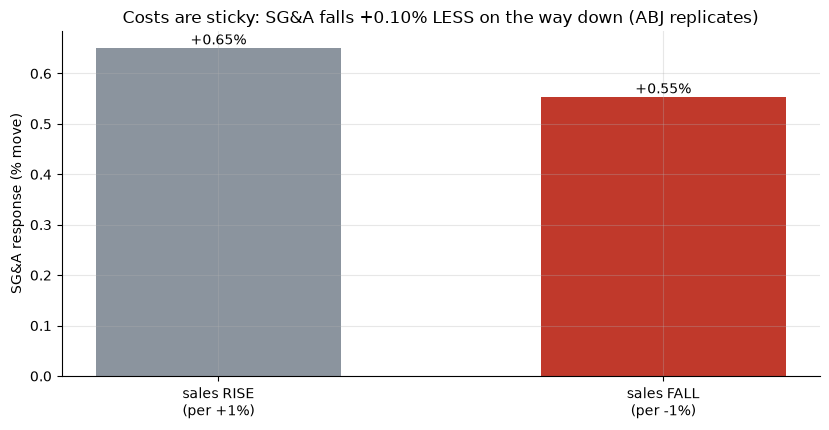

SG&A rises +0.65% per +1% sales, falls only +0.55% per -1% sales -> asymmetry β₂ = -0.097 (sticky).


In [2]:
up, dn = R['abj_b1'], R['abj_b1p2']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['sales RISE\n(per +1%)', 'sales FALL\n(per -1%)'], [up, dn],
       color=[GREY, RED], width=.55)
for i,v in enumerate([up, dn]): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('SG&A response (% move)')
ax.set_title(f'Costs are sticky: SG&A falls {up-dn:+.2f}% LESS on the way down (ABJ replicates)')
plt.tight_layout(); plt.show()
print(f'SG&A rises {up:+.2f}% per +1% sales, falls only {dn:+.2f}% per -1% sales '
      f'-> asymmetry β₂ = {R["abj_b2"]:+.3f} (sticky).')

There it is — SG&A comes down **+0.10 percentage points less** per unit of sales decline than it goes up per unit of sales gain. The Anderson-Banker-Janakiraman effect is real and it replicates on our names. Costs genuinely cling on the way down.

**So now the money question: do the sticky firms under-earn?** Same firms, ranked from leanest to stickiest; we buy the lean third and short the sticky third and measure the forward *return*.

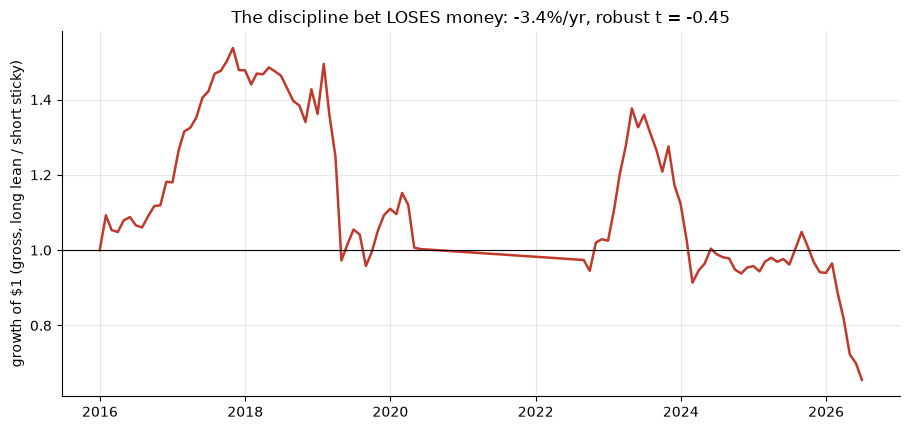

long lean / short sticky: -3.4%/yr gross, Newey-West t = -0.45 (the bar is |t|>=2)


In [3]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='disc', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ann, tnw = s['ann_pct'], s['t_nw']
    cum = (1+ls['ls']).cumprod()
else:
    ann, tnw = R['ls_ann'], R['ls_t_nw']
    cum = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if cum is not None:
    ax.plot(cum.index, cum.values, color=RED, lw=1.8)
    ax.axhline(1.0, c='k', lw=.8)
    ax.set_ylabel('growth of $1 (gross, long lean / short sticky)')
    ax.set_title(f'The discipline bet LOSES money: {ann:+.1f}%/yr, robust t = {tnw:+.2f}')
else:
    ax.text(.5,.5,'run with cache for the equity curve',ha='center'); ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f'long lean / short sticky: {ann:+.1f}%/yr gross, Newey-West t = {tnw:+.2f} (the bar is |t|>=2)')

It **slopes down**. Buying discipline and shorting stickiness lost money — **-3.4%/yr**, shrinking \$1 to \$0.66 over 101 months. That's not just 'no edge', it's the *opposite* of the claim's sign — the sticky firms slightly out-returned the lean ones. But before you flip the trade: the robust *t* is **-0.45**, nowhere near significance, and it **flips to positive** if you change how stale a signal you'll tolerate. It's noise wearing a sign.

**The tell:** if stickiness really sorted returns, the middle third would sit between the ends. And when we look across horizons, the spread can't even hold one sign.

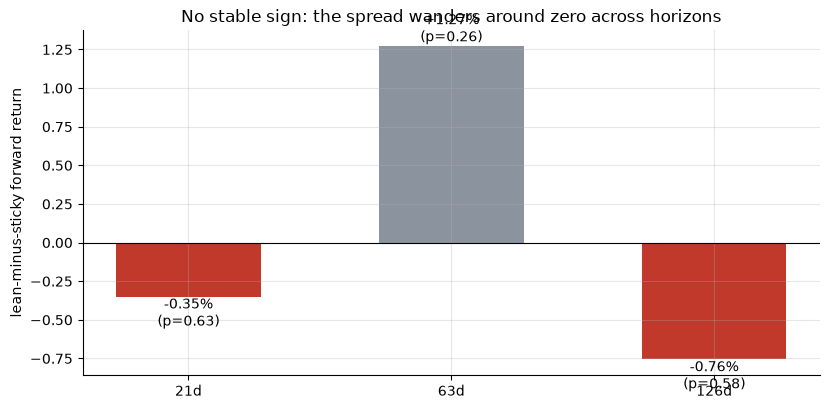

lean-minus-sticky drift by horizon: ['-0.35% (placebo p=0.63)', '+1.27% (placebo p=0.26)', '-0.76% (placebo p=0.58)']


In [4]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=3000)
        rows.append((h, es['ls_mean']*100, es['t'], es['p_placebo']))
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[6]))
hs=[f'{r[0]}d' for r in rows]; vals=[r[1] for r in rows]
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(hs, vals, color=[RED if v<0 else GREY for v in vals], width=.55)
for i,(h,v,t,p) in enumerate(rows): ax.annotate(f'{v:+.2f}%\n(p={p:.2f})',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('lean-minus-sticky forward return')
ax.set_title('No stable sign: the spread wanders around zero across horizons')
plt.tight_layout(); plt.show()
print('lean-minus-sticky drift by horizon:', [f'{v:+.2f}% (placebo p={p:.2f})' for h,v,t,p in rows])

The spread is negative at 1 month, positive at 1 quarter, negative again at 2 quarters — and a **random relabelling of the firms beats the real ranking** a quarter to six-tenths of the time (placebo *p* ≈ 0.25-0.62). There is no ladder and no stable direction. Whatever cost stickiness is telling you, it isn't telling you which stock to own.

## 5 · The verdict

- **Is SG&A sticky? — Confirmed.** SG&A rises +0.65% per 1% sales gain, falls only +0.55% per 1% sales loss. The ABJ phenomenon is real.
- **Signal (returns) — None.** The discipline long-short is the wrong sign (-3.4%/yr), insignificant (robust *t* = -0.45), sign-unstable, and the event drift can't hold a direction. No effect either way.
- **Weaker future profits? — No.** The stickiest third's next-year ROA change is only -0.14 pp different from the leanest — statistically nothing.
- **Tradability — Mirage.** You can't get paid for a spread that isn't there.

> The honest one-liner: *costs really are sticky — and the market could not care less which firms let them stick.*

## 6 · Going further 🚪

- **Where an edge might still hide.** Not in the *level* of a public cost elasticity, but maybe in the *surprise* — a firm that suddenly stops cutting when analysts expect discipline — or in stickiness interacted with leverage or a live downturn. That's the residual this study didn't chase.
- **The coverage caveat is real.** Only firms that actually *decline* identify stickiness, so the panel is thin (25 of 33 names), cyclical-tilted, and the quarterly firm-level β₂ is noisy — attenuation could bury a weak true effect. But the profits regression is a flat zero too, which makes a hidden return edge unlikely.
- **Sibling studies:** [524-operating-leverage](../../524-operating-leverage/) (the *size* of the cost-to-sales elasticity), [200-roe-quality](../../200-roe-quality/) and [122-gross-profitability](../../122-gross-profitability/) (profitability *levels*), [749-layoff-drift](../../749-layoff-drift/) (an announced cost-cut *event*). See [docs/references.md](docs/references.md) for the exact dedup.

*Think the alpha is in the stickiness *surprise*, not the level? Build the expectation model, show a certifiable net spread on the size you'd actually run — then we'll talk.*